<a href="https://colab.research.google.com/github/nithinrb/NVIDIA/blob/main/DAY_8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
pip install diffusers transformers accelerate torch pillow

In [5]:

from diffusers import StableDiffusionImg2ImgPipeline
from PIL import Image
import torch

# Select device
device = "cuda" if torch.cuda.is_available() else "cpu"

# Load Stable Diffusion Image-to-Image Model
pipe = StableDiffusionImg2ImgPipeline.from_pretrained(
    "runwayml/stable-diffusion-v1-5",
    torch_dtype=torch.float16 if device == "cuda" else torch.float32
)

pipe = pipe.to(device)

# Load Input Cat Image
init_image = Image.open("img.jpeg").convert("RGB")
init_image = init_image.resize((512, 512))

# Prompt
prompt = """
A cute fluffy white cat sitting in a magical garden,
highly detailed, realistic, cinematic lighting,
4k quality
"""

# Generate New Image
result = pipe(
    prompt=prompt,
    image=init_image,
    strength=0.6,      # 0-1 (higher = more changes)
    guidance_scale=7.5
)

generated_image = result.images[0]

# Save Output
generated_image.save("generated_cat.png")

print("Image generated successfully!")


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

  0%|          | 0/30 [00:00<?, ?it/s]

Image generated successfully!


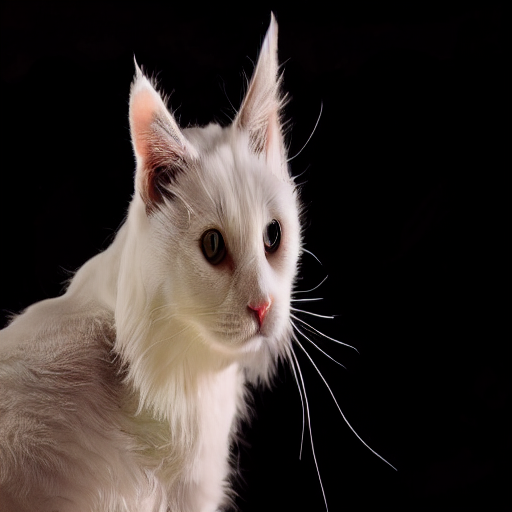

In [6]:
from IPython.display import Image
Image("generated_cat.png")